In [45]:
import polars as pl
import sqlite3
import matplotlib.pyplot as plt
from great_tables import GT

problem_name = "jobshop"
metrics = ["db_size", "cp_size", "computation_time", "quality"]


In [46]:
conn = sqlite3.connect("numeric_bench.db")

df = (
    pl
    .read_database(f"SELECT instance_id, factorized, use_bp, db_size, cp_size, num_bp, computation_time, quality FROM {problem_name}", connection=conn)
    .with_columns([
        pl.lit(problem_name).alias("problem_type"),
        pl.col("factorized").cast(pl.Boolean),
        pl.col("use_bp").cast(pl.Boolean),
    ])
)
print(df)


shape: (160, 9)
┌─────────────┬────────────┬────────┬─────────┬───┬────────┬──────────────┬─────────┬──────────────┐
│ instance_id ┆ factorized ┆ use_bp ┆ db_size ┆ … ┆ num_bp ┆ computation_ ┆ quality ┆ problem_type │
│ ---         ┆ ---        ┆ ---    ┆ ---     ┆   ┆ ---    ┆ time         ┆ ---     ┆ ---          │
│ i64         ┆ bool       ┆ bool   ┆ i64     ┆   ┆ i64    ┆ ---          ┆ f64     ┆ str          │
│             ┆            ┆        ┆         ┆   ┆        ┆ f64          ┆         ┆              │
╞═════════════╪════════════╪════════╪═════════╪═══╪════════╪══════════════╪═════════╪══════════════╡
│ 22          ┆ true       ┆ true   ┆ 123562  ┆ … ┆ 100    ┆ 2.204        ┆ 845.5   ┆ jobshop      │
│ 22          ┆ true       ┆ false  ┆ 127955  ┆ … ┆ -1     ┆ 3.728        ┆ 2085.7  ┆ jobshop      │
│ 22          ┆ false      ┆ true   ┆ 92602   ┆ … ┆ 100    ┆ 2.138        ┆ 845.5   ┆ jobshop      │
│ 22          ┆ false      ┆ false  ┆ 58596   ┆ … ┆ -1     ┆ 2.424        ┆

In [47]:
summary = (
    df
    .group_by(["factorized", "use_bp"])
    .agg([pl.mean(metric) for metric in metrics])
)
(
    GT(summary)
    .tab_header(title="Average Metrics by Configuration")
    .fmt_number(
        columns=metrics,
        decimals=2,
        compact=True,
    )
    .show()
)

Average Metrics by Configuration 
 
 
 factorized 
 use_bp 
 db_size 
 cp_size 
 computation_time 
 quality 
 
 
 
 
 false 
 false 
 158.02K 
 200.34K 
 16.27 
 3.15K 
 
 
 true 
 false 
 354.17K 
 200.66K 
 27.20 
 2.55K 
 
 
 false 
 true 
 253.27K 
 110.14K 
 23.71 
 1.35K 
 
 
 true 
 true 
 340.57K 
 110.47K 
 24.17 
 1.35K

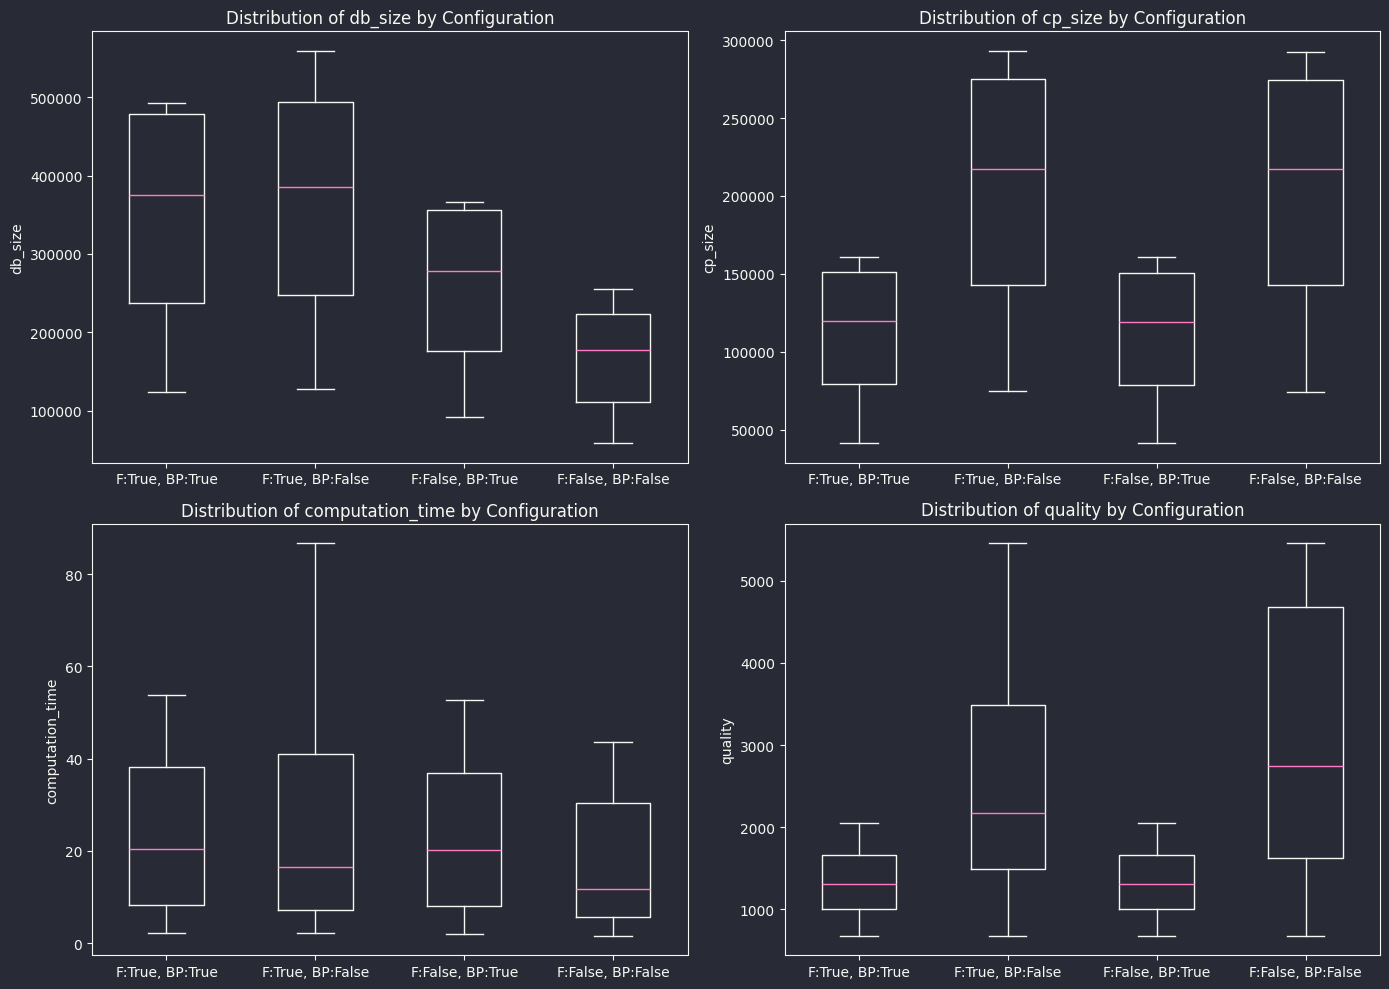

In [48]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for idx, metric in enumerate(metrics):
    ax = axs[idx]
    labels = []
    for i, (factorized, use_bp) in enumerate([(True, True), (True, False), (False, True), (False, False)]):
        subset = df.filter((pl.col("factorized") == factorized) & (pl.col("use_bp") == use_bp))
        ax.boxplot(subset[metric].to_numpy(), positions=[i], widths=0.5)
        labels.append(f"F:{factorized}, BP:{use_bp}")
    
    ax.set_title(f"Distribution of {metric} by Configuration")
    ax.set_xticks(range(4))
    ax.set_xticklabels(labels)
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

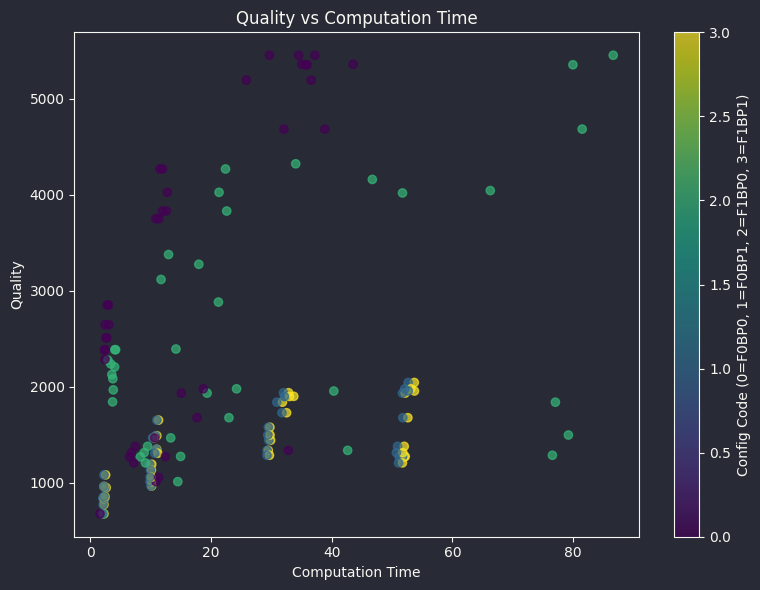

In [49]:
colors = df.select([
    (pl.col("factorized") * 2 + pl.col("use_bp")).alias("config_code")
]).to_numpy().flatten()

plt.figure(figsize=(8, 6))
plt.scatter(df["computation_time"], df["quality"], c=colors, alpha=0.7)
plt.xlabel("Computation Time")
plt.ylabel("Quality")
plt.title("Quality vs Computation Time")
plt.colorbar(label="Config Code (0=F0BP0, 1=F0BP1, 2=F1BP0, 3=F1BP1)")
plt.tight_layout()
plt.show()

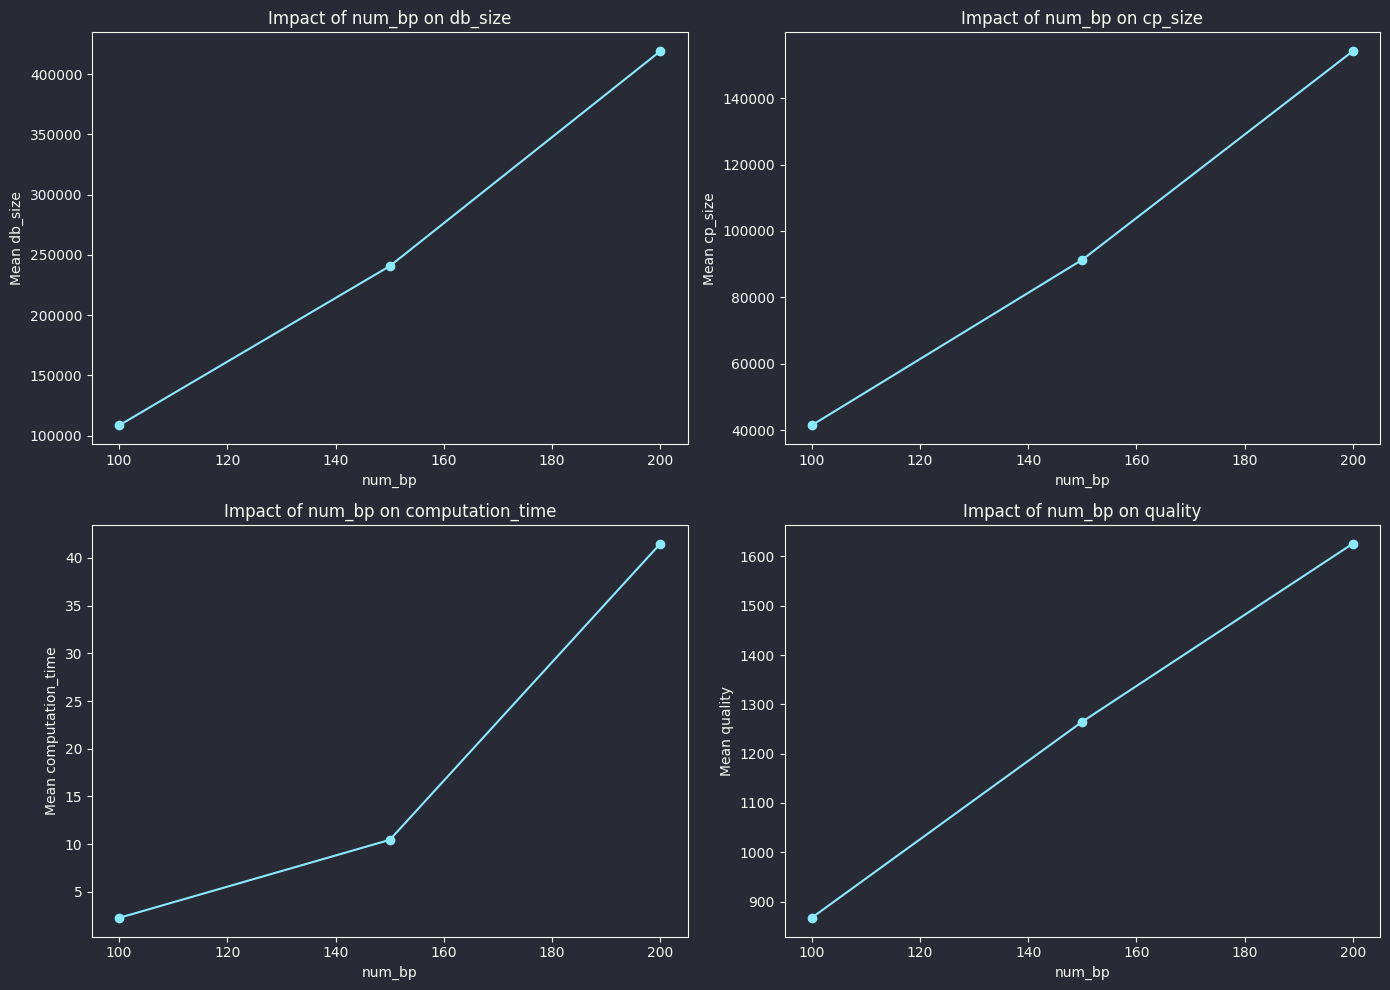

In [50]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for idx, metric in enumerate(metrics):
    # Filter out rows where num_bp == -1 (not applicable)
    filtered = df.filter(pl.col("num_bp") != -1)
    # Group by num_bp and compute mean of the metric
    grouped = (
        filtered.group_by("num_bp")
        .agg([pl.mean(metric).alias(f"mean_{metric}")])
        .sort("num_bp")
    )
    axs[idx].plot(grouped["num_bp"], grouped[f"mean_{metric}"], marker='o')
    axs[idx].set_title(f"Impact of num_bp on {metric}")
    axs[idx].set_xlabel("num_bp")
    axs[idx].set_ylabel(f"Mean {metric}")

plt.tight_layout()
plt.show()